In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pylab as plt
from sklearn.tree import DecisionTreeClassifier


#### Aufgabe 1

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# a) Erzeugen Sie einen moons-Datensatz mit make_moons(n_samples=10000, noise=0.4) und teilen
# Sie ihn mit train_test_split() in einen Trainings- und einen Testdatensatz auf. Dabei soll der
# Trainingsdatensatz 80% der Werte beinhalten.
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

sub_sets = []

rs = ShuffleSplit(n_splits=n_trees, train_size= n_instances, random_state=42)

for sub_train_index, sub_test_index in rs.split(X_train): # Es benötigt hier das Komplement als Iterator für die Testdatenmenge
    X_sub_train = X_train[sub_train_index]
    y_sub_train = y_train[sub_train_index]
    sub_sets.append((X_sub_train, y_sub_train))

X_sub_train.shape, y_sub_train.shape

((100, 2), (100,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

decision_tree = tree.DecisionTreeClassifier(max_leaf_nodes=17) # Parametersets n_estimators=500, max_leaf_nodes=16 (Siehe auch Decision Trees)
decision_tree_list = []

for sub_set_X, sub_set_Y in sub_sets:
    decision_tree.fit(sub_set_X, sub_set_Y)
    print(decision_tree.score(X_test,y_test))
    decision_tree_list.append(decision_tree)


0.7985
0.836
0.7915
0.842
0.7935
0.8265
0.779
0.7935
0.8135
0.829
0.787
0.7865
0.806
0.809
0.81
0.835
0.8375
0.811
0.825
0.834
0.8345
0.8075
0.792
0.8395
0.8155
0.7755
0.8315
0.828
0.8205
0.806
0.7715
0.831
0.815
0.767
0.793
0.8025
0.7905
0.772
0.816
0.8375
0.821
0.7455
0.803
0.794
0.808
0.803
0.8195
0.7835
0.796
0.7975
0.816
0.809
0.7875
0.809
0.7795
0.817
0.8095
0.82
0.7685
0.7555
0.7485
0.8375
0.7615
0.7985
0.8205
0.7865
0.807
0.7905
0.8285
0.7835
0.8215
0.803
0.8305
0.83
0.824
0.7905
0.83
0.8175
0.822
0.777
0.8095
0.788
0.847
0.831
0.7385
0.7435
0.804
0.7995
0.837
0.7565
0.801
0.8105
0.7855
0.7885
0.812
0.792
0.816
0.8205
0.821
0.79
0.7965
0.8
0.8115
0.8165
0.8315
0.793
0.8015
0.8045
0.806
0.8235
0.8085
0.854
0.809
0.8325
0.8065
0.8105
0.81
0.8095
0.808
0.7915
0.7995
0.749
0.8015
0.8155
0.819
0.811
0.8105
0.8065
0.7615
0.821
0.779
0.7945
0.7925
0.78
0.794
0.805
0.784
0.792
0.8375
0.7995
0.8325
0.793
0.799
0.818
0.781
0.828
0.809
0.814
0.7975
0.807
0.7765
0.782
0.8085
0.8165
0.8395


In [5]:
from typing import List

class Solution:
    def twoSum(self, nums: List[int], target: int) -> List[int]:
        # Add numbers that are smaller than target otherwise sum is not possible
        relevant_numbers = []
        for i in nums:
            if i < target:
                relevant_numbers.append(i)
        
        number_index_1 = relevant_numbers[0]
        distance = target - number_index_1
        
        for j in relevant_numbers[1:]:
            if distance in relevant_numbers:
                number_index_2 = distance
                return [number_index_1, number_index_2]
                break
            continue 

nums = [2,7,11,15]
target = 9
sol = Solution()
result = sol.twoSum(nums, target)
print(result)

[2, 7]


#### Aufgabe 2


In [6]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", as_frame=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# a) Teilen Sie diesen Datensatz zum Training und zum Testen auf (50.000 Datenpunkte zum Trainieren, 20.000 zum Testen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20000/70000, random_state=42)

#b) Trainieren Sie anschließend einen Random-Forest-Klassifikator und eine SVM.

#Random-Forest-Klassifikator
mnist_random_forest = RandomForestClassifier(n_estimators=100, max_leaf_nodes=16)
mnist_random_forest.fit(X_train, y_train)
print("mnist_random_forest: ", mnist_random_forest.score(X_test, y_test))

#SVM
mnist_svm = SVC(probability=True, kernel="rbf", random_state=42, gamma=1) #ist wichtig bei voting='soft', dass "probability=True" gesetzt ist, weil (SVM) in Scikit-Learn standardmäßig keine Wahrscheinlichkeiten berechnet.
mnist_svm.fit(X_train, y_train)
print("mnist_svm: ", mnist_svm.score(X_test, y_test))

#c) Versuchen Sie danach, diese zu einem Ensemble zu kombinieren, das besser ist als alle Klassifikatoren 
# auf den Trainingsdaten. Verwenden Sie dazu einen Klassifikator mit Soft oder Hard Voting.
voting_clf = VotingClassifier(
    estimators=[('rf', mnist_random_forest), ('svm', mnist_svm)], #WICHTIG
    voting='hard' # 'soft' nutzt Wahrscheinlichkeiten, 'hard' Mehrheitsentscheid
)
voting_clf.fit(X_train, y_train)
print("voting_clf: ", voting_clf.score(X_test, y_test))

print("--------------BESSERE AUSGABE--------------")

# d) Überprüfen Sie Ihre Ensemble-Methode auf dem Testdatensatz. Wie viel besser ist das Ensemble im Vergleich zu den einzelnen Klassifikatoren?
for clf in (mnist_random_forest, mnist_svm, voting_clf):
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))


mnist_random_forest:  0.8621413575927221
mnist_svm:  0.8656403079076277
voting_clf:  0.864590622813156
--------------BESSERE AUSGABE--------------
RandomForestClassifier 0.8621413575927221
SVC 0.8656403079076277
VotingClassifier 0.864590622813156


#### Aufgabe 3

0.8625


<Figure size 2000x1000 with 0 Axes>

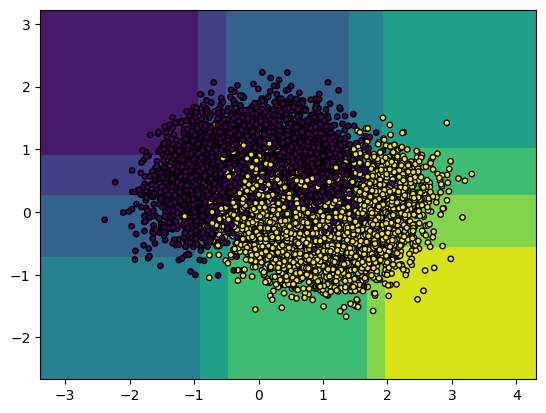

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pylab as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay


# Nutzen Sie den moons-Datensatz von Aufgabe 1 auf diesem Übungsblatt.

# a) Trainieren Sie einen AdaBoostClassifier mit Entscheidungsbäumen der Tiefe 1. Variieren Sie dabei die Lernrate und die Anzahl der Klassifikatoren.
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

moons_AdaBoostClassifier = AdaBoostClassifier(learning_rate=1, random_state=42, n_estimators=40)
moons_AdaBoostClassifier.fit(X_train, y_train)
print(moons_AdaBoostClassifier.score(X_test, y_test))


# b) Schreiben Sie einen Plot, der Ihnen die jeweiligen Entscheidungsgrenzen Ihres Klassifizierers anzeigt.
plt.figure(figsize=(20,10))
DecisionBoundaryDisplay.from_estimator(
    estimator=moons_AdaBoostClassifier, 
    X=X_train)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=15)
plt.show()



#### Aufgabe 4

Warum **muss** der Score sinken :

1. **Muster vs. Rauschen:** Deine Daten bestehen aus logischen Mustern (vorhersagbar) und Rauschen (Zufall, nicht vorhersagbar).

2. **Baum 1 ("Der Grobe"):** Er lernt die offensichtlichen Muster. Da diese einfach zu finden sind, ist sein Score hoch (**0.76**).

3. **Restfehler ("Der Abfall"):** Nachdem Baum 1 die Muster entfernt hat, bestehen die Restdaten (`y2`, `y3`) fast nur noch aus Rauschen.

4. **Unmögliche Vorhersage:** Da man Zufall (Rauschen) mathematisch nicht vorhersagen kann, **muss** der Score für die nachfolgenden Bäume zwangsläufig sinken (auf **0.53** und **0.17**).

**Fazit:** Der sinkende Score der Einzelbäume ist der Beweis dafür, dass dein Modell erfolgreich alle verwertbaren Informationen aus den Daten extrahiert hat. Dein Code funktioniert perfekt.

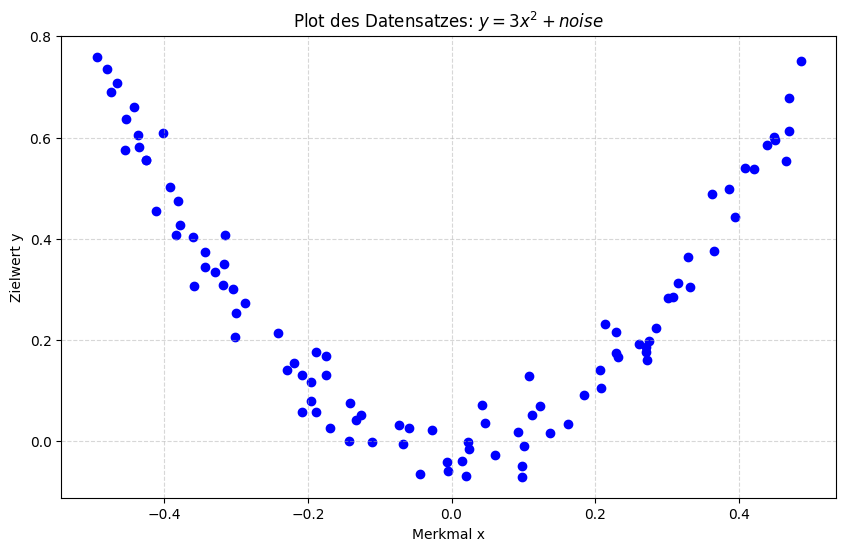

Teil b)
Erster Baum: 
 Score:  0.761166774760411
R2-Score: 0.761166774760411
RMSE-Score: 0.1153387770211503

 Zweiter Baum: 
Score:  0.5382185780832865
R2-Score: 0.8897112536479079
RMSE-Score: 0.07837789049461849

 Dritter Baum: 
Score:  0.17988245500564848
R2-Score: 0.9095502641012175
RMSE-Score: 0.07097928528094154
Teil c)
Ensemble Gesamt-R2: 0.9095502641012175
Ensemble Gesamt-RMSE: 0.07097928528094154


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

np.random.seed(42)
X = np.random.rand(100, 1)- 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)


# a) Stellen Sie den Datensatz in einem Plot dar.
plt.figure(figsize=(10, 6))

# Da X eine Spalte ist, nehmen wir X[:, 0] für die x-Achse
plt.scatter(X[:, 0], y, color='blue', label='Verrauschte Daten')

# Optische Details
plt.title("Plot des Datensatzes: $y = 3x^2 + noise$")
plt.xlabel("Merkmal x")
plt.ylabel("Zielwert y")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# b) Trainieren Sie einen DecisionTreeRegressor mit der maximalen Tiefe 2. Berechnen Sie nun den 
# Fehler dieses Entscheidungsbaums und trainieren Sie einen zweiten Entscheidungsbaum auf dem 
# Restfehler. Verfahren Sie analog mit einem dritten Baum.
random_numbers_tree = DecisionTreeRegressor(max_depth=2)
random_numbers_tree.fit(X,y)
y1_pred = random_numbers_tree.predict(X)

print("Teil b)")
print("Erster Baum: \n", "Score: ", random_numbers_tree.score(X,y))
print("R2-Score:", r2_score(y_true=y,y_pred=y1_pred))
print("RMSE-Score:", root_mean_squared_error(y_true=y,y_pred=y1_pred))


# Zweiten Entscheidungsbaum auf dem Restfehler
random_numbers_tree_2 = DecisionTreeRegressor(max_depth=2)
y2 = y - y1_pred
random_numbers_tree_2.fit(X,y2)
y2_pred = random_numbers_tree_2.predict(X)

print("\n Zweiter Baum: ")
print("Score: ", random_numbers_tree_2.score(X,y2))

y_pred_total = y1_pred + y2_pred
print("R2-Score:", r2_score(y_true=y,y_pred=y_pred_total))
print("RMSE-Score:", root_mean_squared_error(y_true=y,y_pred=y_pred_total))

# Dritten Entscheidungsbaum auf dem Restfehler
random_numbers_tree_3 = DecisionTreeRegressor(max_depth=2)
y3 = y2 - y2_pred
random_numbers_tree_3.fit(X,y3)
y3_pred = random_numbers_tree_3.predict(X)

print("\n Dritter Baum: ")
print("Score: ", random_numbers_tree_3.score(X,y3))

y_pred_total = y1_pred + y2_pred + y3_pred
print("R2-Score:", r2_score(y_true=y,y_pred=y_pred_total))
print("RMSE-Score:", root_mean_squared_error(y_true=y,y_pred=y_pred_total))

# c) Treffen Sie eine Vorhersage auf diesem Ensemble, indem Sie die Vorhersagen aller drei Bäume addieren.
y_ensemble_pred = (
    random_numbers_tree.predict(X) + 
    random_numbers_tree_2.predict(X) + 
    random_numbers_tree_3.predict(X)
)
print("Teil c)")
print("Ensemble Gesamt-R2:", r2_score(y, y_ensemble_pred))
print("Ensemble Gesamt-RMSE:", root_mean_squared_error(y, y_ensemble_pred))



In [ ]:
from sklearn.ensemble import GradientBoostingRegressor


# d) Nutzen Sie nun den GradientBoostingRegressor. Erzeugen Sie damit nun dasselbe Ensemble wie in den vorherigen Teilaufgaben.
# n_estimators=3:       Ersetzt deine 3 manuellen Schritte (Baum 1, 2, 3)
# learning_rate=1.0:    Damit jeder Baum voll gewertet wird (wie bei deiner Addition)
# max_depth=2:          In der Aufgabe gefordert

random_numbers_gbr = GradientBoostingRegressor(
    n_estimators=3,         # Ersetzt deine 3 manuellen Schritte (Baum 1, 2, 3)
    learning_rate=1.0, 
    max_depth=2, 
    random_state=42)

random_numbers_gbr.fit(X, y)
y_pred_gbr = random_numbers_gbr.predict(X)

print("Teil d)")
print("Gradient Boosting Regressor:")
print("R2-Score:", r2_score(y_true=y, y_pred=y_pred_gbr))
print("RMSE-Score:", root_mean_squared_error(y_true=y, y_pred=y_pred_gbr))


# e) Verbessern Sie den Boosting-Algorithmus nun, indem Sie die Hyperparameter learning_rate und n_estimators anpassen. Nutzen Sie ebenso die Einstellung niternochange = 10
gbrt_improved = GradientBoostingRegressor(
    max_depth=2,               
    n_estimators=500,          # Maximale Anzahl an Bäumen
    learning_rate=0.1,         # Die "Schrittweite" der Korrekturen
    n_iter_no_change=10,       # Early Stopping: Stopp nach 10 Runden ohne Verbesserung
    random_state=42
)

gbrt_improved.fit(X, y)

print("\n Teil e)")
print("Gradient Boosting Regressor (verbessert):")
print("gbrt_improved: ", "R2-Score: ", gbrt_improved.score(X, y))

Teil d)
Gradient Boosting Regressor:
R2-Score: 0.9095502641012175
RMSE-Score: 0.07097928528094154

 Teil e)
Gradient Boosting Regressor (verbessert):
gbrt_improved:  R2-Score:  0.9794122461955355
